# Dye Variability

As the next step, we will collect multiple single stain spectra measurements, and prepare them to be used in the full standardisation.

While we use data from conventional flow cytometry here, everything applies in exactly the same way to spectral flow cytometry.

In [1]:
import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import PIL

#import cytovanni

import sys
local_path = os.path.expanduser("~/cytovanni_publish/Cytovanni/src")
if local_path not in sys.path:
    sys.path.insert(0, local_path)
import cytovanni
cytovanni.__version__

'1.1.0'

In [2]:
raw_data_path = os.path.expanduser("~/Cytovanni/data/example_variable-spectra/")
data_path = os.path.expanduser("~/Cytovanni/docs/tutorials/integration_variable-spectra/")

In [3]:
cytoconfig = cytovanni.utils.CytometerConfiguration_A3()

## Load Spectra

First, we need to load all the individual single stain spectra.

In [4]:
meta_run = pd.read_table(os.path.join(data_path, "single_stain", "meta_run.csv"), sep=",", index_col=0)
runs = meta_run["run"]
runs

0        HD7_CompensationM_20230904_Sidentity1
1        HD7_CompensationM_20230904_Sidentity2
2           HD7_CompensationM_20230915_Stcell2
3           HD7_CompensationM_20230920_Stcell3
4         HD7_CompensationM_20230921_Sidentity
5            HD7_CompensationM_20230921_Stcell
6         HD7_CompensationM_20240411_Sidentity
7            HD7_CompensationM_20240411_Stcell
8     HD7_CompensationM_20240411_Stcell_failed
9         HD7_CompensationM_20240514_Sidentity
10           HD7_CompensationM_20240514_Stcell
11        HD7_CompensationM_20240515_Sidentity
12           HD7_CompensationM_20240515_Stcell
13          HD7_Compensation_20230816_identity
14             HD7_Compensation_20231117_tcell
15          HD7_Compensation_20240131_identity
16          HD7_Compensation_20240219_identity
17             HD7_Compensation_20240219_tcell
18          HD7_Compensation_20240320_identity
19          HD7_Compensation_20240417_identity
20             HD7_Compensation_20240417_tcell
21          H

We also load an assignment of each dye to its main emission channel.

In [5]:
key_dye_channel = pd.read_table(os.path.join(raw_data_path, "single_stain", "meta_dye_channel.csv"), sep=",", index_col=0)["channel"]
key_dye_channel

APC                        APC-A
APC-Cy7                 APC-H7-A
APC-H7                  APC-H7-A
APC-R700              APC-R700-A
Alexa Flour 700       APC-R700-A
BB515                    BB515-A
BB700                    BB700-A
BUV395                  BUV396-A
BUV496                  BUV496-A
BUV563                  BUV563-A
BUV615                  BUV615-A
BUV661                  BUV661-A
BUV737                  BUV737-A
BUV805                  BUV805-A
BV421                    BV421-A
BV605                    BV605-A
BV650                    BV650-A
BV711                    BV711-A
BV750                    BV750-A
BV786                    BV786-A
FITC                     BB515-A
PE (BD)                 BYG584-A
PE (BioLegend)          BYG584-A
PE-CF594              PE-CF594-A
PE-Cy5                  BYG670-A
PE-Cy7 (BD)             BYG790-A
PE-Cy7 (BioLegend)      BYG790-A
PE-Vio770               BYG790-A
PE/Dazzle 594         PE-CF594-A
eflour                   BV510-A
Name: chan

For comparison, we load the raw spectra as they were measured.

In [6]:
spillovers_raw = pd.Series([
    cytovanni.spill.SpilloverMeasurement.from_csv(
         os.path.join(data_path, "single_stain", run, "spectra.csv"),
         os.path.join(data_path, "single_stain", run, "panel_meta.csv"),
         is_spectral=False, clip_negative=True)
    for run in runs], index=runs)
spcollection_raw = cytovanni.spill.SpilloverCollection(spillovers_raw, register_on="dye")

However, the main data is the calibrated spectra that were produced in the previous step.

In [7]:
spillovers = pd.Series([
    cytovanni.spill.SpilloverMeasurement.from_csv(
         os.path.join(data_path, "single_stain", run, "spectra_calibrated.csv"),
         os.path.join(data_path, "single_stain", run, "panel_meta.csv"),
         is_spectral=False, clip_negative=True)
    for run in runs], index=runs)
spcollection = cytovanni.spill.SpilloverCollection(spillovers, register_on="dye")

We also need to ensure a consistent normalization of the spectra, i.e. the same channel should be normalized to one for every measurement. We can either just use the channel with the highest intensity for every dye:

In [8]:
spcollection_raw.normalize_spectra()
spcollection.normalize_spectra()

It is also possible to pick the channel to be normalized for every dye explicitly:

In [9]:
spcollection_raw.normalize_spectra(key_dye_channel)
spcollection.normalize_spectra(key_dye_channel)

## Rainbow Bead Calibration Effect

Looking at the raw spectra of a single dye, we see that there is a large amount of variation between measurements:

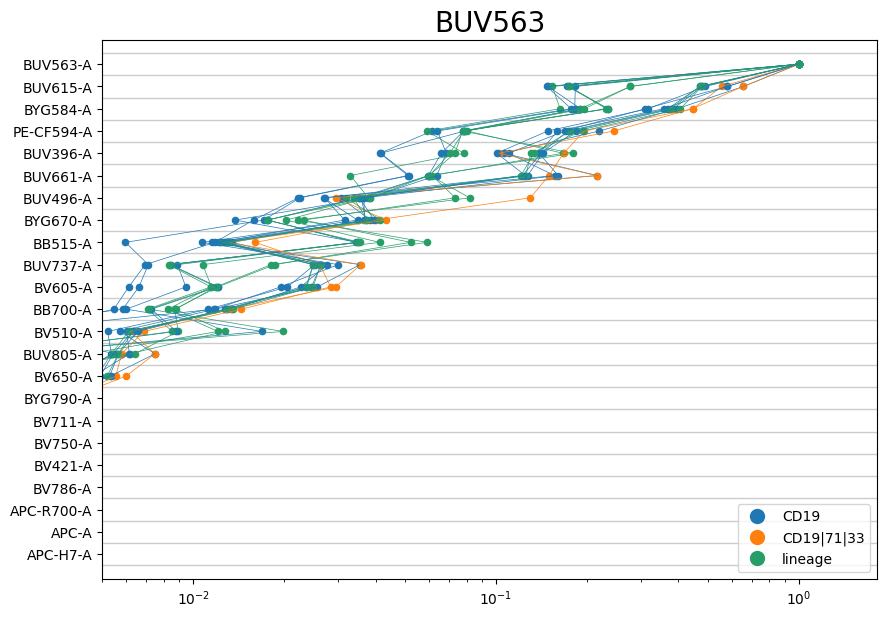

In [10]:
spcollection_raw.plot_spectrum("BUV563", "spectra", "antigen")

However, calibrating the flow cytometer yields much more consistent spectra. Note also that we do not see any effect of which antibody is conjugated to the fluorophore.

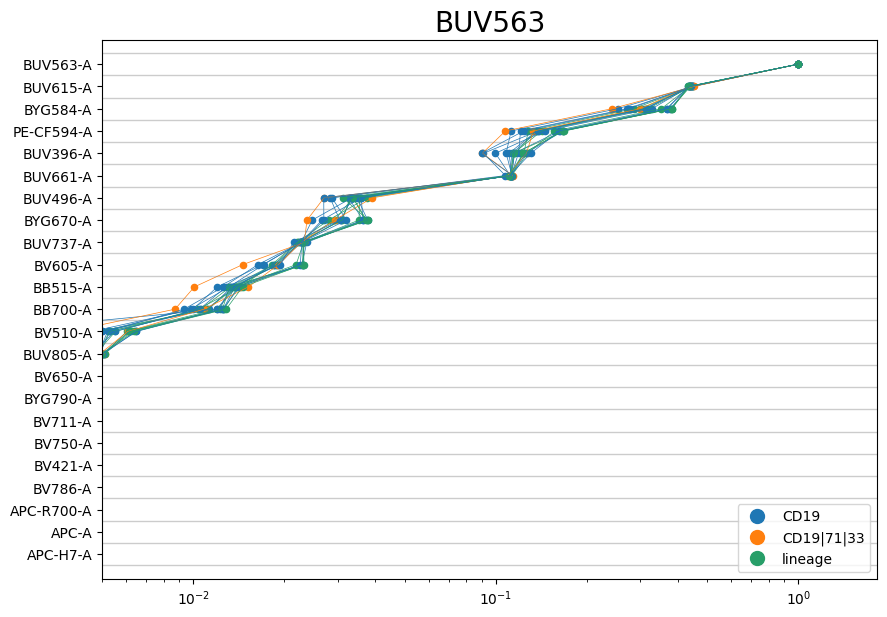

In [11]:
spcollection.plot_spectrum("BUV563", "spectra", "antigen")

## Distinguishing Dyes

Above, we index spectra by the fluorophore name. This is cleaner for our final purpose, however it makes comparing different fluorophores harder. We therefore load the data again, but this time indexed on the corresponding channel for every fluorophore:

In [12]:
spillovers_raw_ci = pd.Series([
    cytovanni.spill.SpilloverMeasurement.from_csv(
         os.path.join(data_path, "single_stain", run, "spectra.csv"),
         os.path.join(data_path, "single_stain", run, "panel_meta.csv"),
         is_spectral=False, clip_negative=True)
    for run in runs], index=runs)
for sp in spillovers_raw_ci:
    sp.panel_meta.index = sp.panel_meta["channel"].to_numpy()
    sp.spectra["spectra"].columns = sp.panel_meta["channel"].to_numpy()
spcollection_raw_ci = cytovanni.spill.SpilloverCollection(spillovers_raw_ci, register_on="channel")
spcollection_raw_ci.normalize_spectra()

In [13]:
spillovers_ci = pd.Series([
    cytovanni.spill.SpilloverMeasurement.from_csv(
         os.path.join(data_path, "single_stain", run, "spectra_calibrated.csv"),
         os.path.join(data_path, "single_stain", run, "panel_meta.csv"),
         is_spectral=False, clip_negative=True)
    for run in runs], index=runs)
for sp in spillovers_ci:
    sp.panel_meta.index = sp.panel_meta["channel"].to_numpy()
    sp.spectra["spectra"].columns = sp.panel_meta["channel"].to_numpy()
spcollection_ci = cytovanni.spill.SpilloverCollection(spillovers_ci, register_on="channel")
spcollection_ci.normalize_spectra()

BB515 and FITC are distinct enough to be distinguishable even in the raw data, while PE-CF594 and PE/Dazzle 594 are not:

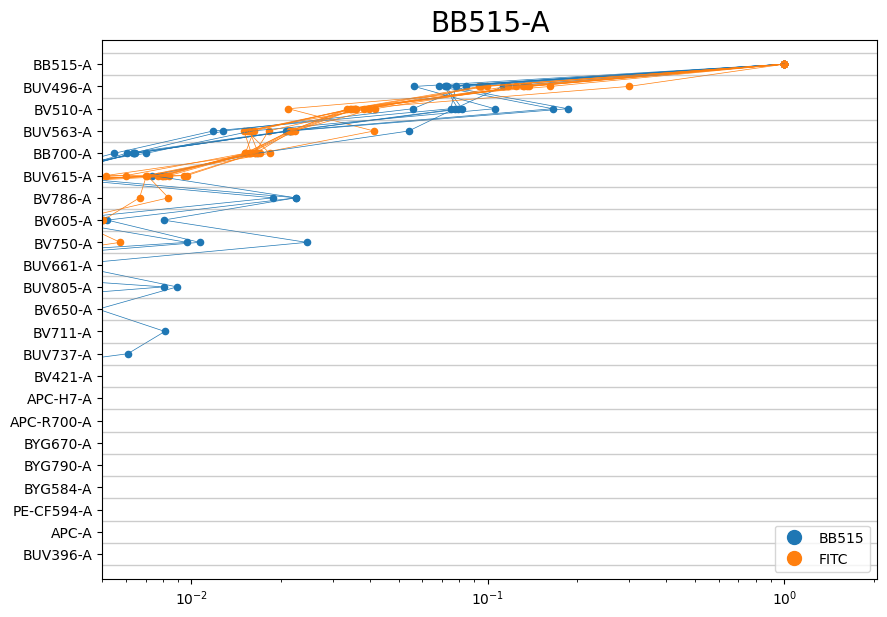

In [14]:
spcollection_raw_ci.plot_spectrum("BB515-A", "spectra", "dye")

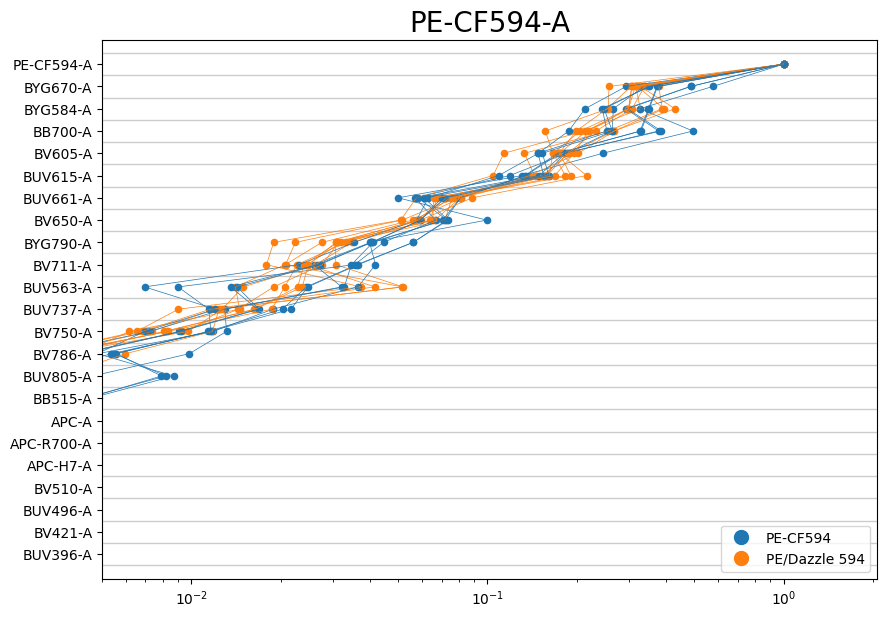

In [15]:
spcollection_raw_ci.plot_spectrum("PE-CF594-A", "spectra", "dye")

After cytometer calibration, both cleanly separate:

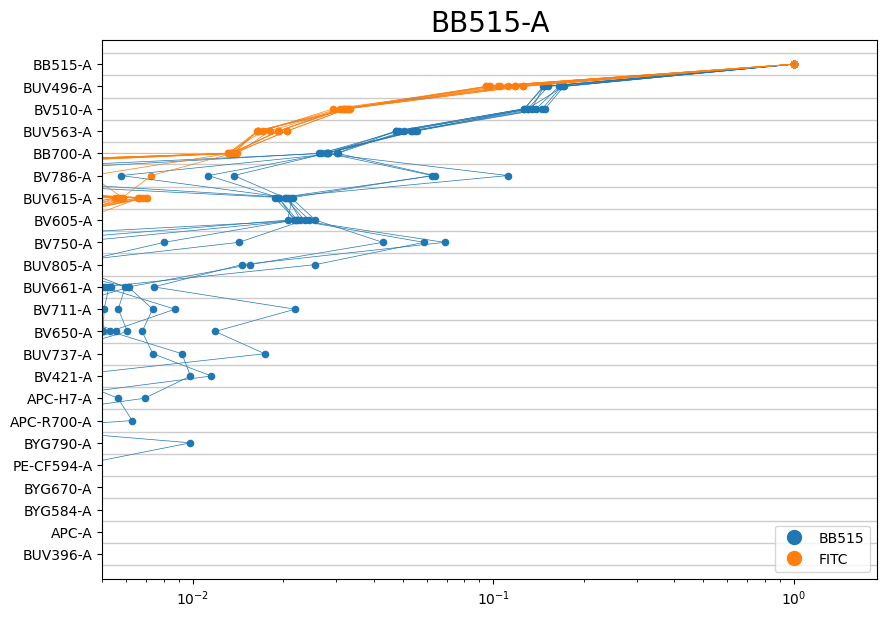

In [16]:
spcollection_ci.plot_spectrum("BB515-A", "spectra", "dye")

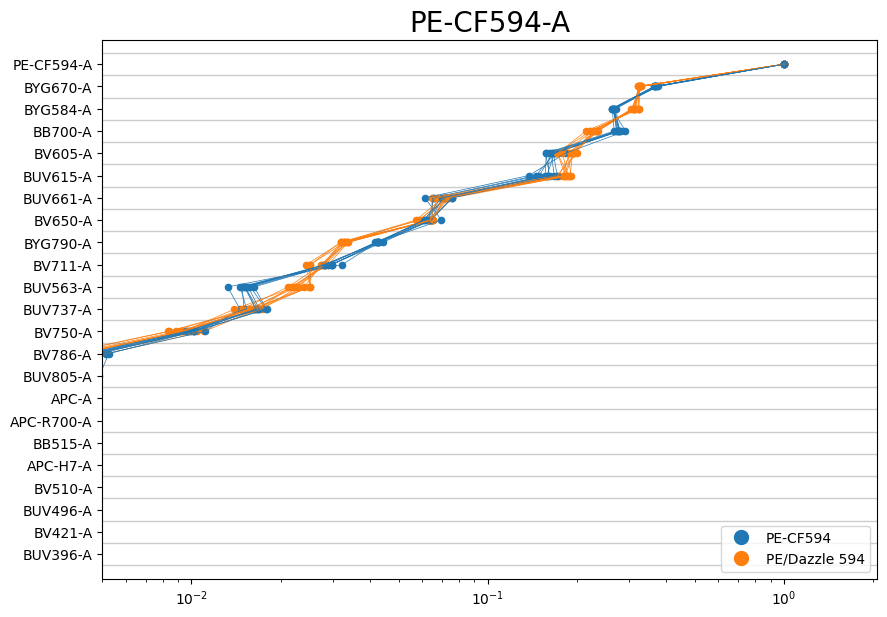

In [17]:
spcollection_ci.plot_spectrum("PE-CF594-A", "spectra", "dye")

## Correlated Variation

The variation that is still present after calibration is highly correlated across different channels:

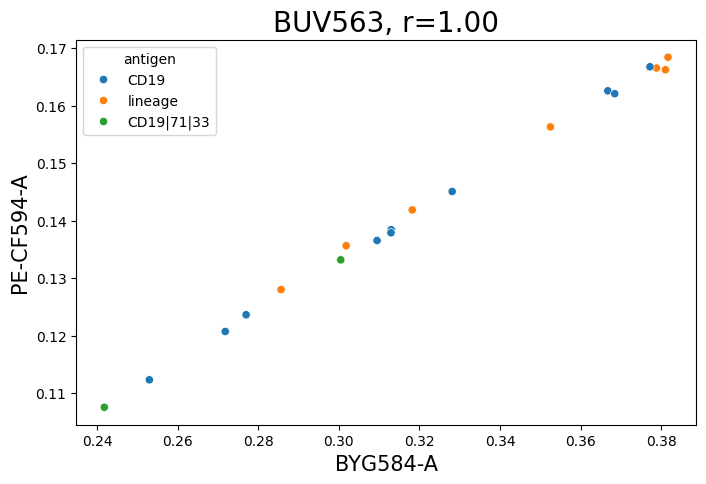

In [18]:
spcollection.plot_spectrum_correlation_single("BUV563", "spectra", "BYG584-A", "PE-CF594-A", "antigen")

We can leverage this correlation to reduce the effective dimensionality of the spectra variability. Performing a PCA on the spectra, we can see that for most dyes, the first one or two components capture the vast majority of the variability:

(1e-06, 0.1)

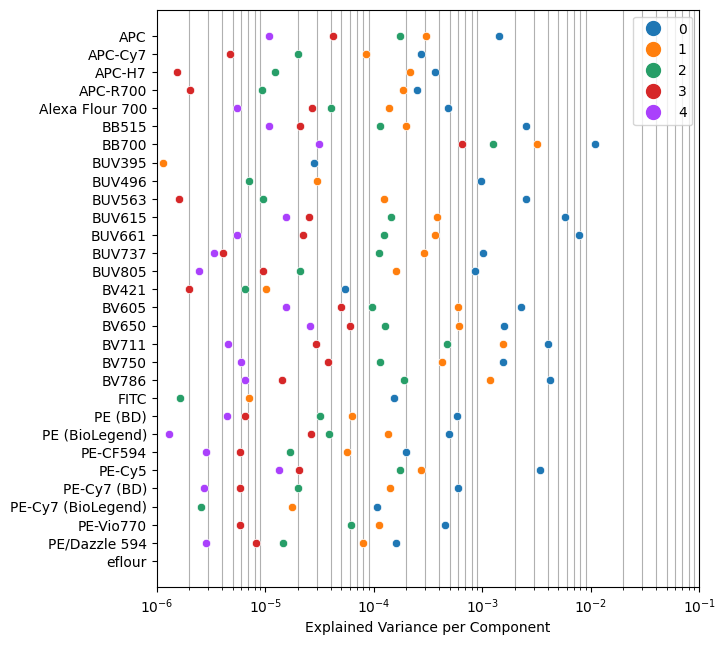

In [19]:
spcollection.add_PCA_fit("spectra")
ax = spcollection.plot_explained_variance()
ax.set_xlim([1e-6,1e-1])

On the left, we show the correlation between emission into different channels, on the right the share of variance per channel that is captured by a given principal component. As expected, the variation mostly consists of blocks of highly correlated channels.

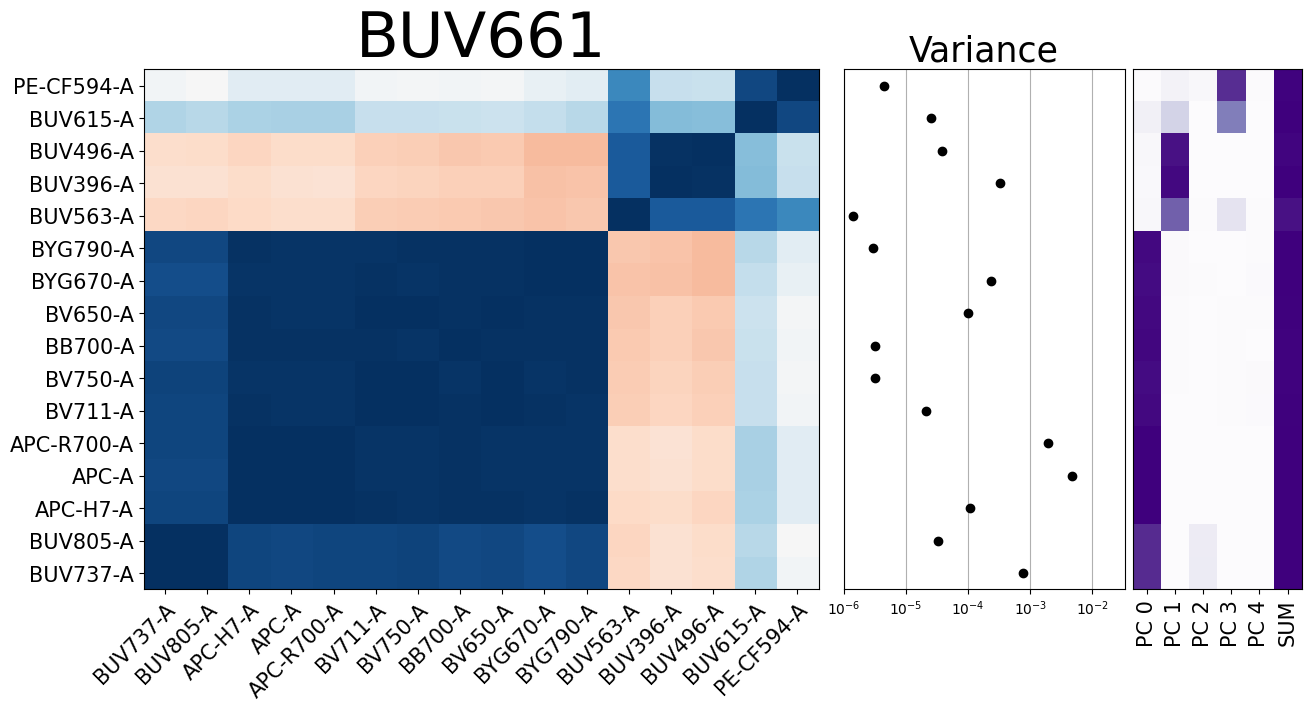

In [20]:
spcollection["BUV661"].plot_spill_correlations_pcafit()

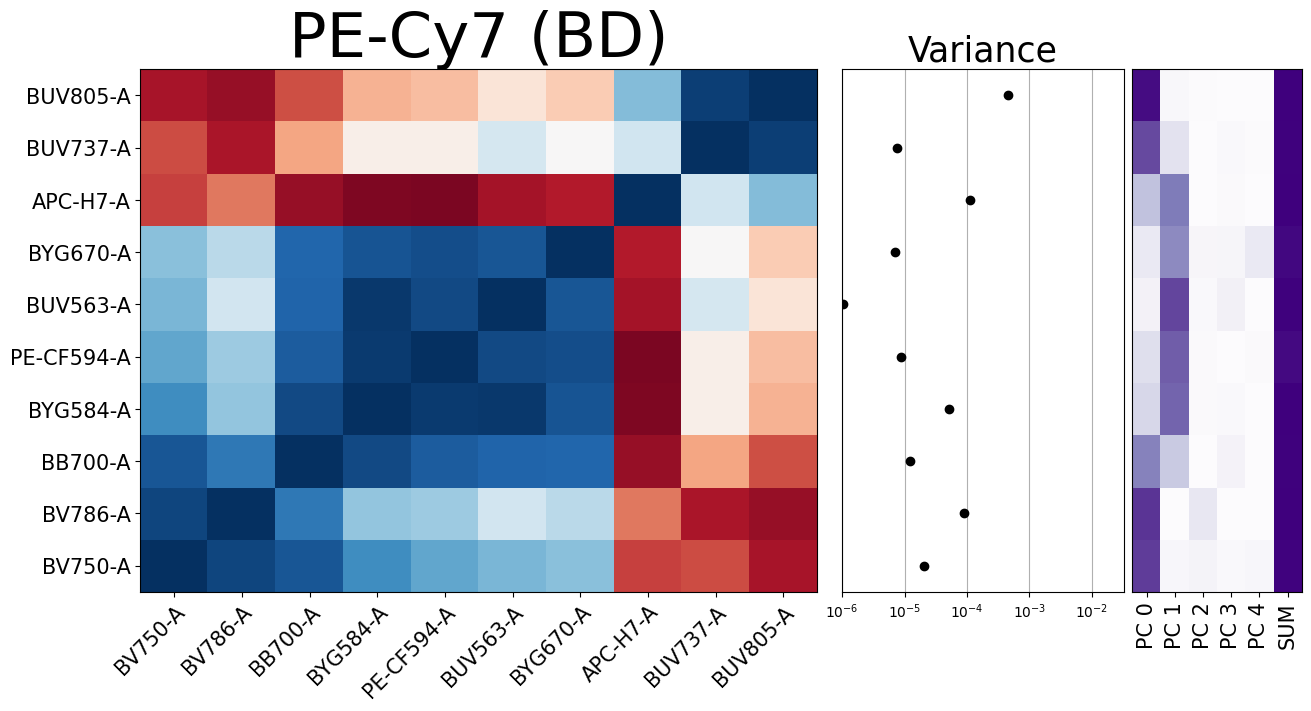

In [21]:
spcollection["PE-Cy7 (BD)"].plot_spill_correlations_pcafit()

## Final Panel Embedding

We now need to choose a set of principal components to include in our model. This is done through a .csv file that contains a column for the dye name and its associated marker, as well as a choice of components per dye. Here, '' doesn't use any components, '0' only the first one, '02' the first and third one etc.

In [22]:
pd.read_table(data_path+"single_stain/panel_HD7_TCell.csv", sep=",", dtype=str)

,stain,marker,components
0,BUV395,CD4,0
1,BUV496,CD8,0
2,BUV563,CD19|71|33,01
3,BUV615,CD314,012
4,BUV661,CXCR3,012
5,BUV737,CD38,012
6,BUV805,CD45RO,01
7,BV421,CD28,0
8,BV605,CD103,0
9,BV650,CD279,01


Which components to choose is to some degree guesswork, although we will later show how it is possible to find components that are missing from the model if errors in the final standardisation are spotted.

We chose them through a combination of using the components that explain the largest amount of variance, as well as whether they look unique.

In [23]:
panelconfig = cytovanni.spill.PanelConfiguration.from_csv(data_path+"single_stain/panel_HD7_TCell.csv", "HD7_TCell")
panelconfig

PanelConfiguration 'HD7_TCell'. Contains 23 dyes, uses 37 PC components.
    BUV395                   CD4
    BUV496                   CD8
    BUV563            CD19|71|33
    BUV615                 CD314
    BUV661                 CXCR3
    BUV737                  CD38
    BUV805                CD45RO
    BV421                   CD28
    BV605                  CD103
    BV650                  CD279
    BV711                   CD94
    BV750                  TCRab
    BV786                   CD95
    eflour              livedead
    FITC                  CD45RA
    BB700                   CD69
    PE (BioLegend)          CD39
    PE-CF594                CD25
    PE-Cy5                 ITGB7
    PE-Cy7 (BD)            TCRgd
    APC                    CD197
    APC-R700               CD127
    APC-H7                   CD3

We can visualize the choice based on how much variance the chosen components explain:

(1e-05, 0.1)

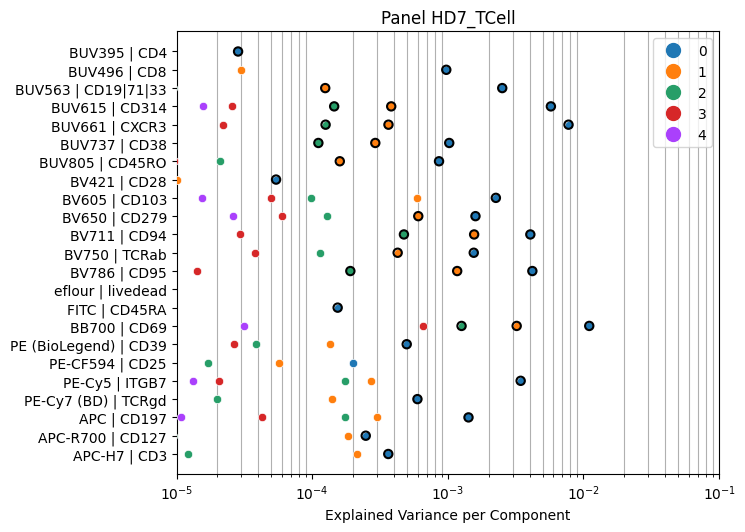

In [24]:
ax = spcollection.plot_explained_variance_panel(panelconfig)
ax.set_xlim([1e-5,1e-1])

We then collect the associated component data and save the resulting panel configuration.

In [25]:
panelconfig.collect_PCA_data(spcollection)
panelconfig.save(data_path+"single_stain/panel_HD7_TCell.pt")

Another option to check whether the chosen components are reasonable is to see how well they reproduce the measured spectra.

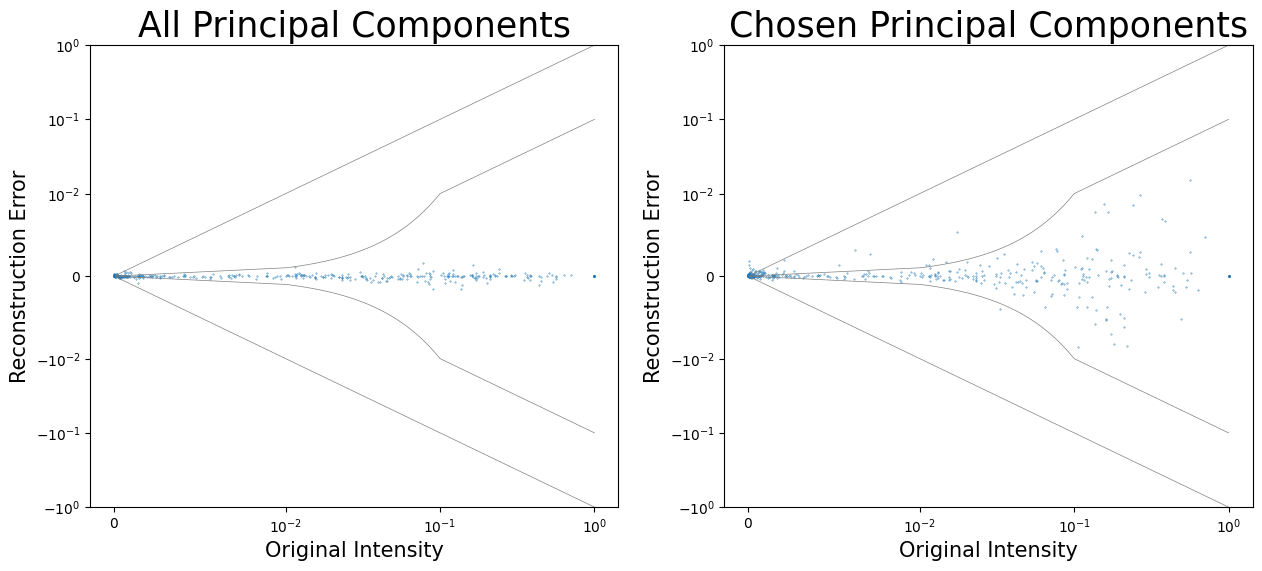

In [27]:
spectra = panelconfig.get_run_spectra("HD7_Compensation_20240417_tcell")
diff = panelconfig.plot_test_spectra_reconstruction(spectra) # gray lines correspond to 100% and 10% error of the reconstruction

As an example, we use a modified panel configuration where we dropped PC0 for BUV496.

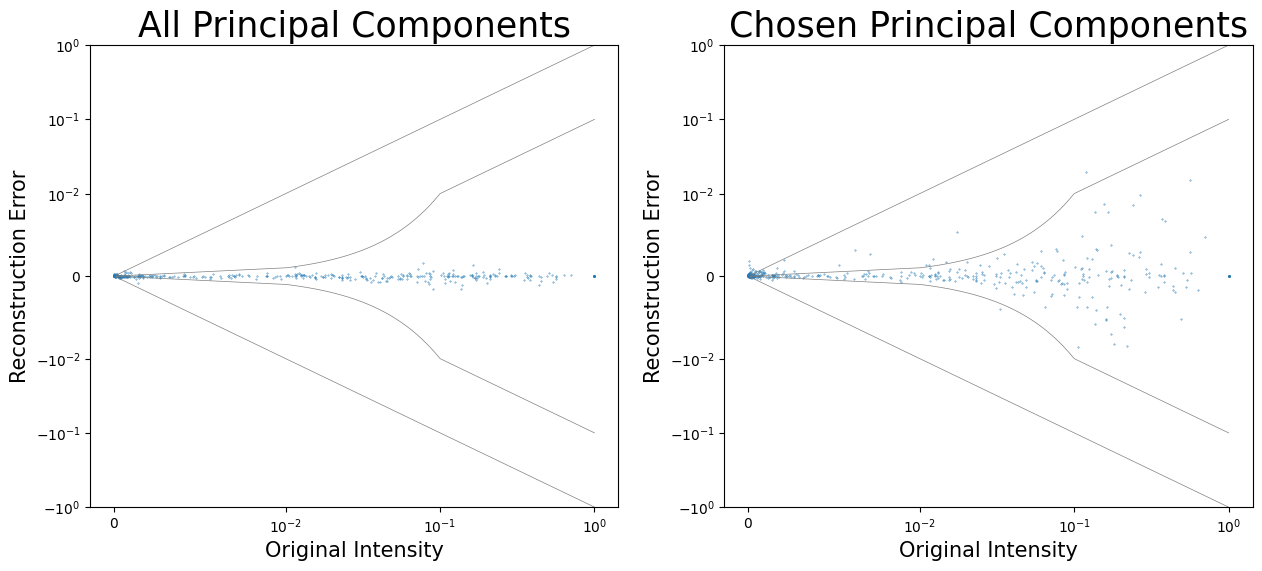

In [28]:
panelconfig_mod = cytovanni.spill.PanelConfiguration.from_csv(data_path+"single_stain/panel_HD7_TCell_modified.csv", "HD7_TCell_modified")
panelconfig_mod.collect_PCA_data(spcollection)
panelconfig_mod.save(data_path+"single_stain/panel_HD7_TCell_modified.pt")
diff = panelconfig_mod.plot_test_spectra_reconstruction(spectra)

We now see that the spectrum of BUV496 has the highest absolute reconstruction error, as expected in channels whose variation is captured by PC0:

In [29]:
diff.sort_values(ascending=False)[:10]

BUV496 | BUV396-A         0.019526
APC | APC-R700-A          0.015191
PE-CF594 | BB700-A        0.009859
PE-CF594 | BV605-A        0.008728
BV605 | BUV615-A          0.008614
PE-Cy7 (BD) | APC-H7-A    0.008595
BV605 | PE-CF594-A        0.008459
PE-Cy5 | BUV661-A         0.008202
BV750 | BV711-A           0.007811
APC | APC-H7-A            0.007777
dtype: float64

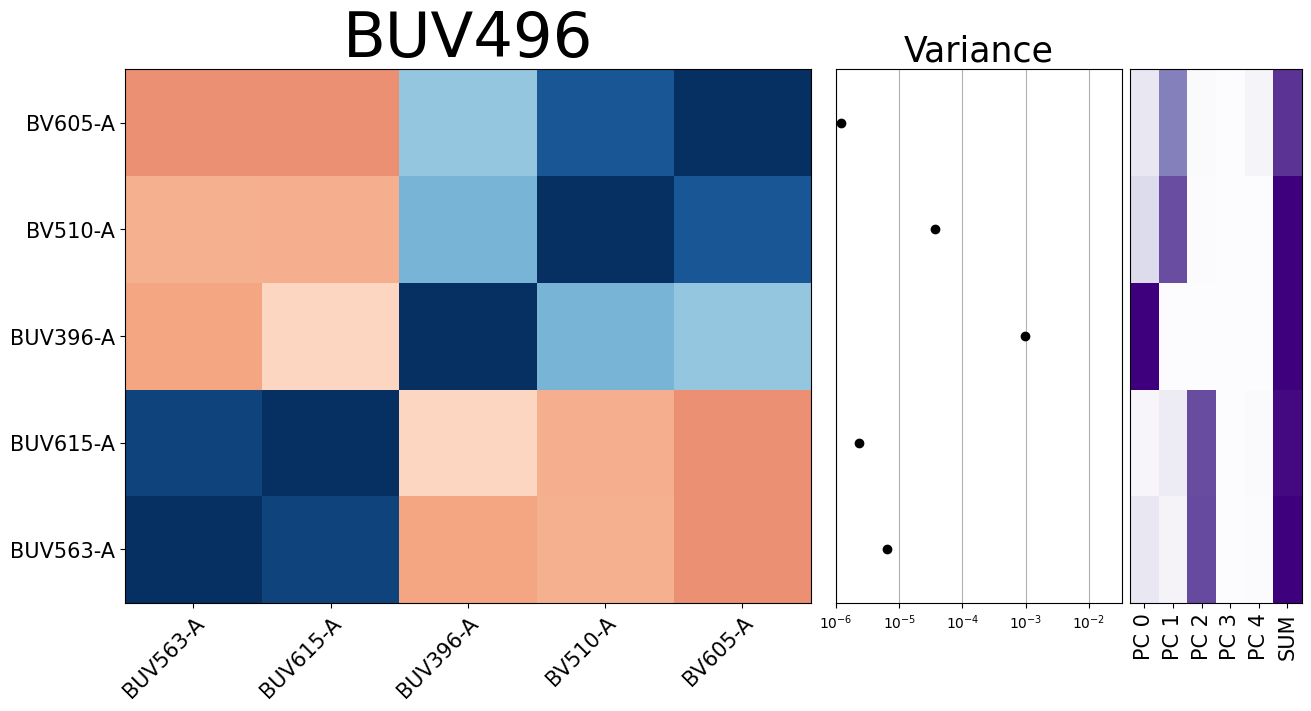

In [30]:
spcollection["BUV496"].plot_spill_correlations_pcafit()

However, the absolute error is not necessarily a good metric for unmixing errors. So another option is to get the reconstructed spectra, and compare the unmixing using them with that of the original spectra.

In [31]:
spectra_reconstructed = panelconfig.get_spectra_from_embedding(panelconfig.get_spectra_embedding(spectra), only_included_components=True)

In [33]:
spectra_reconstructed

,BB515-A,BB700-A,APC-A,APC-H7-A,APC-R700-A,BUV396-A,BUV496-A,BUV563-A,BUV615-A,BUV661-A,...,BV510-A,BV605-A,BV650-A,BV711-A,BV750-A,BV786-A,BYG584-A,BYG670-A,BYG790-A,PE-CF594-A
BUV395,0.000042,0.000050,0.000023,0.000055,0.000024,1.000000,0.073802,0.006620,0.002341,0.000692,...,0.000241,0.000072,0.000021,0.000000,0.000014,0.000006,0.000094,0.000063,0.000014,0.000057
BUV496,0.016421,0.000946,0.000095,0.000109,0.000244,0.119645,1.000000,0.210570,0.088298,0.025833,...,0.173942,0.025188,0.005634,0.002503,0.000919,0.000513,0.000338,0.000213,0.000045,0.000245
BUV563,0.013724,0.012746,0.000126,0.000052,0.000123,0.114597,0.031477,1.000000,0.434713,0.111541,...,0.005766,0.022956,0.004632,0.002028,0.000618,0.000303,0.381731,0.037707,0.003123,0.168033
BUV615,0.000074,0.011951,0.004192,0.000356,0.002461,0.064278,0.013540,0.115920,1.000000,0.451188,...,0.000251,0.088489,0.034642,0.015333,0.005476,0.002340,0.189682,0.193388,0.020097,0.505497
BUV661,0.000064,0.012932,0.567884,0.079723,0.353936,0.042473,0.010249,0.002422,0.037632,1.000000,...,0.000156,0.003800,0.083063,0.038269,0.013892,0.006460,0.001082,0.120286,0.012519,0.006632
BUV737,0.000045,0.111903,0.004593,0.171670,0.365898,0.057158,0.012619,0.001528,0.001143,0.011524,...,0.000220,0.000055,0.000595,0.025758,0.044754,0.022639,0.000131,0.000449,0.009985,0.000278
BUV805,0.000206,0.000984,0.000824,0.102477,0.008151,0.232130,0.055238,0.009803,0.007066,0.004179,...,0.000840,0.000256,0.000245,0.000312,0.003031,0.056282,0.000643,0.000560,0.009059,0.000674
BV421,0.000071,0.000120,0.000073,0.000150,0.000249,0.001045,0.069932,0.007287,0.002642,0.000903,...,0.160628,0.011109,0.002501,0.001452,0.001300,0.000916,0.000059,0.000077,0.000024,0.000058
BV605,0.000028,0.013771,0.001461,0.000483,0.001195,0.000508,0.001794,0.059108,0.249674,0.141688,...,0.004617,1.000000,0.435218,0.200934,0.083096,0.043918,0.165028,0.100165,0.012450,0.212798
BV650,0.000117,0.007299,0.127036,0.018538,0.080600,0.000180,0.001985,0.001358,0.045623,0.303343,...,0.006114,0.225123,1.000000,0.488690,0.166441,0.078342,0.001335,0.068897,0.007762,0.012587
